In [323]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import pyparsing as pp
from scipy.spatial.distance import cdist
from sklearn.preprocessing import MinMaxScaler

In [324]:
query = {
  "k": 10,
  "seed": {
    "artist": "Gorillaz",
    "song": "Feel Good Inc.",
    "album_name": ""
  },
  "features": {
    "popularity": 0,
    "danceability": 1.0,
    "energy": 1.0,
    "key": 0,
    "valence": 1.0,
    "tempo": 0,
    "duration_ms": 0
  },
  "constraints": {
    "include": {
      "genres": [],
      "lang": [],
      "artist": [],
      "song": [],
      "album_name": [],
      "release": [],
       "tags" : []
    },
    "exclude": {
      "genres": [],
      "lang": [],
      "artist": ["Gorillaz"],
      "song": [],
      "album_name": [],
      "release": [],
     "tags" : [],
    }
  }
}

In [325]:
query["seed"]

{'artist': 'Gorillaz', 'song': 'Feel Good Inc.', 'album_name': ''}

In [326]:
metadata_df = pd.read_csv("id_metadata.csv",  sep="\t")
info_df = pd.read_csv("id_information.csv",  sep="\t")
lang_df = pd.read_csv("id_lang.csv",  sep="\t")
genres_df = pd.read_csv("id_genres.csv",  sep="\t")
tags_df = pd.read_csv("id_tags.csv",  sep="\t")
dataframes = [metadata_df, info_df, lang_df, genres_df, tags_df]


In [327]:
metadata_df.head()

,id,spotify_id,popularity,release,danceability,energy,key,mode,valence,tempo,duration_ms
0,0009fFIM1eYThaPg,3eObKIfHKJ1nAPh0wTxFCc,12.0,2009,0.635,0.746,6.0,1.0,0.548,110.973,229947
1,0010xmHR6UICBOYT,27szvF97Tu95GxN98N52fy,46.0,2013,0.591,0.513,7.0,0.0,0.263,172.208,325096
2,002Jyd0vN4HyCpqL,273lBFpxUCwisTpdnF9cVb,31.0,1974,0.319,0.925,2.0,1.0,0.658,157.630,285693
3,006TYKNjNxWjfKjy,1qZgergQ41vaD4zBf3AKXR,33.0,2017,0.432,0.979,7.0,1.0,0.162,90.008,332867
4,007LIJOPQ4Sb98qV,6rVxJ3sN3Cz40MSLavbG1K,19.0,2009,0.357,0.708,9.0,1.0,0.470,123.904,326067


In [328]:
scaler = MinMaxScaler()
# apply MinMaxScalar to tempo attribute
metadata_df['tempo'] = scaler.fit_transform(metadata_df[['tempo']])

In [329]:
metadata_df.head()

,id,spotify_id,popularity,release,danceability,energy,key,mode,valence,tempo,duration_ms
0,0009fFIM1eYThaPg,3eObKIfHKJ1nAPh0wTxFCc,12.0,2009,0.635,0.746,6.0,1.0,0.548,0.456861,229947
1,0010xmHR6UICBOYT,27szvF97Tu95GxN98N52fy,46.0,2013,0.591,0.513,7.0,0.0,0.263,0.708958,325096
2,002Jyd0vN4HyCpqL,273lBFpxUCwisTpdnF9cVb,31.0,1974,0.319,0.925,2.0,1.0,0.658,0.648942,285693
3,006TYKNjNxWjfKjy,1qZgergQ41vaD4zBf3AKXR,33.0,2017,0.432,0.979,7.0,1.0,0.162,0.370551,332867
4,007LIJOPQ4Sb98qV,6rVxJ3sN3Cz40MSLavbG1K,19.0,2009,0.357,0.708,9.0,1.0,0.470,0.510097,326067


In [330]:
info_df.head()

,id,artist,song,album_name
0,0009fFIM1eYThaPg,Cheryl,Rain on Me,3 Words
1,0010xmHR6UICBOYT,Oddisee,After Thoughts,The Beauty in All
2,002Jyd0vN4HyCpqL,Blue Öyster Cult,ME 262,Secret Treaties
3,006TYKNjNxWjfKjy,Rhapsody,Flames of Revenge,Legendary Years (Re-Recorded)
4,007LIJOPQ4Sb98qV,The Chameleons,Nostalgia,What Does Anything Mean? Basically (2009 Remas...


In [331]:
lang_df.head()

,id,lang
0,0009fFIM1eYThaPg,en
1,0010xmHR6UICBOYT,en
2,002Jyd0vN4HyCpqL,en
3,006TYKNjNxWjfKjy,en
4,007LIJOPQ4Sb98qV,en


In [332]:
genres_df.head()

,id,genres
0,0009fFIM1eYThaPg,pop
1,0010xmHR6UICBOYT,underground hip hop
2,002Jyd0vN4HyCpqL,"hard rock,rock,classic rock"
3,006TYKNjNxWjfKjy,"symphonic metal,power metal,symphonic power metal"
4,007LIJOPQ4Sb98qV,"post-punk,new wave"


In [333]:
tags_df.head()

,id,tags
0,0009fFIM1eYThaPg,"pop,british,female vocalists,dance,cheryl cole"
1,0010xmHR6UICBOYT,"instrumental hip-hop,underground hip hop,instr..."
2,002Jyd0vN4HyCpqL,"hard rock,rock,classic rock,american artist"
3,006TYKNjNxWjfKjy,"symphonic metal,power metal,symphonic power metal"
4,007LIJOPQ4Sb98qV,"post-punk,new wave,1985"


In [334]:
search_df = pd.concat([metadata_df.set_index("id"), info_df.set_index("id"), 
                       lang_df.set_index("id"), genres_df.set_index("id"), tags_df.set_index("id")], axis=1)
search_df = search_df.reset_index()

In [335]:
search_df.head()

,id,spotify_id,popularity,release,danceability,energy,key,mode,valence,tempo,duration_ms,artist,song,album_name,lang,genres,tags
0,0009fFIM1eYThaPg,3eObKIfHKJ1nAPh0wTxFCc,12.0,2009,0.635,0.746,6.0,1.0,0.548,0.456861,229947,Cheryl,Rain on Me,3 Words,en,pop,"pop,british,female vocalists,dance,cheryl cole"
1,0010xmHR6UICBOYT,27szvF97Tu95GxN98N52fy,46.0,2013,0.591,0.513,7.0,0.0,0.263,0.708958,325096,Oddisee,After Thoughts,The Beauty in All,en,underground hip hop,"instrumental hip-hop,underground hip hop,instr..."
2,002Jyd0vN4HyCpqL,273lBFpxUCwisTpdnF9cVb,31.0,1974,0.319,0.925,2.0,1.0,0.658,0.648942,285693,Blue Öyster Cult,ME 262,Secret Treaties,en,"hard rock,rock,classic rock","hard rock,rock,classic rock,american artist"
3,006TYKNjNxWjfKjy,1qZgergQ41vaD4zBf3AKXR,33.0,2017,0.432,0.979,7.0,1.0,0.162,0.370551,332867,Rhapsody,Flames of Revenge,Legendary Years (Re-Recorded),en,"symphonic metal,power metal,symphonic power metal","symphonic metal,power metal,symphonic power metal"
4,007LIJOPQ4Sb98qV,6rVxJ3sN3Cz40MSLavbG1K,19.0,2009,0.357,0.708,9.0,1.0,0.470,0.510097,326067,The Chameleons,Nostalgia,What Does Anything Mean? Basically (2009 Remas...,en,"post-punk,new wave","post-punk,new wave,1985"


In [336]:
print(search_df.shape)

(109269, 17)


In [337]:
for col in metadata_df.columns:
    print(f"{col} Max {np.max(np.array(metadata_df[col]))}")
    print(f"{col} Min {np.min(np.array(metadata_df[col]))}")
    

id Max zzzwh2ktIWjsR7xp
id Min 0009fFIM1eYThaPg
spotify_id Max 7zzZmpw8L66ZPjH1M6qmOs
spotify_id Min 000CfxgH11DeiTY9oCvZLJ
popularity Max 95.0
popularity Min 0.0
release Max 2019
release Min 1013
danceability Max 0.988
danceability Min 0.0
energy Max 1.0
energy Min 0.0
key Max 11.0
key Min 0.0
mode Max 1.0
mode Min 0.0
valence Max 0.998
valence Min 0.0
tempo Max 1.0
tempo Min 0.0
duration_ms Max 4995315
duration_ms Min 7229


In [338]:
def get_song_id(song, info_df):
    # take selection and projection
    # of id_information to get seed
    # song id from given song title and artist name
    # filter for non empty attributes
    attributes = {k:v for k,v in song.items() if v}

    # get keys and values from filtered attributes
    # with keys selecting for columns
    # and values used for comparison
    cols = list(attributes.keys())
    vals = list(attributes.values())

    # then do selection and take projection of row "id"
    return info_df.loc[(info_df[cols] == vals).all(axis=1), "id"].item()

In [339]:
song_id = get_song_id(query["seed"], search_df)
print(song_id)

uQUCBofXJAQuX3pV


In [340]:
search_df = pd.concat([metadata_df.set_index("id"), info_df.set_index("id"), 
                       lang_df.set_index("id"), genres_df.set_index("id"), tags_df.set_index("id")], axis=1)
search_df = search_df.reset_index()

In [341]:
def parse_expression(col, expr):

    # get attributes that require double qoutes
    # to search on
    qouted = ["artist", "song", "album_name","lang"]
 
    # define boolean operators for filtering
    ops = ['>=', '<=', '>', '<']
    op = pp.one_of(ops)

    # define atom for parsing
    atom = (pp.Optional(op, default="==")) + (pp.Word(pp.nums) | pp.Word(pp.alphas)| pp.quoted_string)
    if col in qouted:
        # ensure we wrap in single qoutes for search
        # i.e use artist=='Gorillaz' instead of 
        # artist==Gorillaz for correct search
        atom.set_parse_action(lambda toks: f"{col}{toks[0]}'{toks[1]}'")
    else:
        atom.set_parse_action(lambda toks: f"{col}"+"".join(toks))
        

    # define pattern
    # use lambda on extracted tokens to add parentheses to expressions
    # i.e year>=2018 & year <= 2025 || year==2005
    # will be returned as ((year>=2018 & year <= 2025)||(year==2005))
    # index on toks[0] as each tok is nested as [['release>=2018', '&', 'release<=2025']]
    pattern = pp.infix_notation(atom, [ ("&", 2, pp.OpAssoc.LEFT,lambda toks: f"({''.join(toks[0])})"),  
                                    ("||", 2, pp.OpAssoc.LEFT,lambda toks: f"({''.join(toks[0])})")])

    # return parsed expression
    return pattern.parse_string(expr)[0]

In [342]:
def get_filtered_metadata(constraints, search_df):
    # genre -> id_genres
    # lang -> id_lang
    # artist, song, album_name -> id_information
    # release -> id_metadata

    # get non empty attributes
    inclusion = {k:v for k,v in constraints["include"].items() if v}
    exclusion = {k:v for k,v in constraints["exclude"].items() if v}
    
    mask = np.full(search_df.shape[0], True)
    for col, vals in inclusion.items():
        # handle genre case separately
        # as genres column contains list of values
        # to compare against
        if col == "genres" or col =="tags":
            mask &= search_df[col].apply(lambda x: any(item.strip()
                                                in list(vals) for item in x.split(",")))    
        else:   
            # loop over all expressions for column
            # init query to be used for filtering
            expressions = []
            for expr in vals:
                # parse each expression
                expr = parse_expression(col, expr)
                expressions.append(expr)   
            
            # join each expression together
            # via conjunction
            query = "|".join(expressions)
            # perform serach on database
            mask &= search_df.eval(query)

        
    for col, vals in exclusion.items():
        # handle genre case separately
        # as genres column contains list of values
        # to compare against
        if col == "genres" or col =="tags":
            mask &= search_df[col].apply(lambda x: any(item.strip()
                                                in list(vals) for item in x.split(","))) 
        else:   
            expressions = []
            for expr in vals:
                expr = parse_expression(col, expr)
                expressions.append(expr)  
            
            query = "|".join(expressions)
         
            mask &= ~search_df.eval(query)
        
    # return result of applying mask
    return search_df[mask]

                                    

In [343]:
filter_df = get_filtered_metadata(query["constraints"],search_df)
    

In [344]:
filter_df.shape

(109194, 17)

In [345]:
def get_feature_vector(song_id, metadata_df, features):
    # given id for selected song
    # retreive assoicated metadata
    # from id_metadata.csv
    # only get features with non-zero weights
    cols = [k for (k, v) in features.items() if v != 0]
    return metadata_df.loc[metadata_df["id"] == song_id, cols].to_numpy()[0]


In [346]:
f_v = get_feature_vector(song_id, metadata_df, query["features"])
f_v

array([0.818, 0.705, 0.772])

In [347]:
def knn(f_v,search_df,features,k,metric,p):
    """
    # compute norm between feature vector
    # and all elements in dataframe
    # using specified parameters to compare against
    dists = np.linalg.norm(metadata_df[list(match.keys())].to_numpy() - f_v, axis=1)
    # find knn indices
    indices = np.argpartition(dists, k)[:k]
    # sort knn indices to get ranked values
    return indices[np.argsort(dists[indices])]
    """
    # compute norm between feature vector
    # and all elements in dataframe
    # using specified parameters to compare against

    cols = [k for (k, v) in features.items() if v != 0]
 
    weights = np.array([v for v in features.values() if v != 0])
    if (metric == 'euclidean'):
        norms = np.linalg.norm(np.sqrt(weights) * (search_df[cols].to_numpy() - f_v), axis=1)   
    elif (metric == 'minkowski'):
        norms = cdist(search_df[cols].to_numpy(), f_v.reshape(1, -1), metric=metric, p=p, w=weights).ravel()
    else:
        norms = cdist(search_df[cols].to_numpy(), f_v.reshape(1, -1), metric=metric).ravel()

    return np.argsort(norms)[:k]



    

In [348]:
k_indices = knn(f_v, search_df, query["features"], 10, 'euclidean', 2)

In [349]:
def get_knn_ids(k_indices, search_df):
    return search_df.iloc[k_indices]["id"]

In [350]:
k_ids = get_knn_ids(k_indices, search_df)
print(k_ids)

19386     B0K6aXBx1WpLX0jl
84453     lvstpqOfgxpMABbt
99387     uQUCBofXJAQuX3pV
7109      3zqjdUMwJRT3t40z
78559     ic2wHo0KxZr1qFqg
75539     guZt5KggjFtPgSr2
89369     olIlprWNeNe5Pdjg
14103     80LS3ppeVurlHCgr
23925     DbhaW4fk1P6CyJHt
100306    uwX8gcHG8LYhFYii
Name: id, dtype: str


In [351]:
def get_knn_recommendations(k_ids, search_df):
    return search_df.set_index("id").loc[k_ids]

In [352]:
knn_recommendations = get_knn_recommendations(k_ids, search_df)
knn_recommendations

,spotify_id,popularity,release,danceability,energy,key,mode,valence,tempo,duration_ms,artist,song,album_name,lang,genres,tags
id,,,,,,,,,,,,,,,,
B0K6aXBx1WpLX0jl,0d28khcov6AiegSCpG5TuT,77.0,2005,0.818,0.705,6.0,1.0,0.772,0.570429,222640,Gorillaz,Demon Days,Demon Days,en,electronic,"alternative,electronic,gorillaz,indie"
lvstpqOfgxpMABbt,0d28khcov6AiegSCpG5TuT,77.0,2005,0.818,0.705,6.0,1.0,0.772,0.570429,222640,Gorillaz,Feel Good Inc,Demon Days,en,"electronic,rock,electronic","alternative,electronic,hip-hop,rock,gorillaz,a..."
uQUCBofXJAQuX3pV,0d28khcov6AiegSCpG5TuT,77.0,2005,0.818,0.705,6.0,1.0,0.772,0.570429,222640,Gorillaz,Feel Good Inc.,Demon Days,en,"electronic,rock","alternative,electronic,hip-hop,rock,gorillaz"
3zqjdUMwJRT3t40z,1eeQoBQzElzDNVcNm5h0uY,29.0,2001,0.822,0.701,6.0,0.0,0.783,0.411724,243800,India.Arie,Part Of My Life,Acoustic Soul,en,soul,"neo-soul,soul,female vocalists,india arie"
ic2wHo0KxZr1qFqg,4d0vE1xdSwNlOXsZOJXjJv,26.0,2017,0.817,0.711,1.0,1.0,0.789,0.494053,264612,Laurel Halo,Moontalk,Dust,en,"electronic,experimental,abstract","electronic,experimental,abstract,sun and moon ..."
guZt5KggjFtPgSr2,4RB3bUNQugfmInfNAO1Cqa,3.0,2016,0.808,0.709,9.0,0.0,0.757,0.564032,185410,El Guincho,Pelo Rapado,Hiperasia,es,"experimental,electronic","experimental,2016,electronic,spanish,tropicali..."
olIlprWNeNe5Pdjg,38casNXY2G39SZRUjALtcY,37.0,2011,0.818,0.710,10.0,1.0,0.791,0.600939,216547,Britney Spears,How I Roll,Femme Fatale (Deluxe Version),en,"pop,electronic,electropop","pop,electronic,kick,electropop,bloodshy and av..."
80LS3ppeVurlHCgr,6JNJERZGJwDVgkmbohBw7u,67.0,1984,0.814,0.686,6.0,0.0,0.779,0.439188,246440,Laura Branigan,Self Control,Self Control,en,pop,"80s,pop,female vocalists,dance"
DbhaW4fk1P6CyJHt,1wxjIhZIcFq3Rrk0zsxHp8,55.0,2018,0.820,0.723,10.0,0.0,0.785,0.395170,201227,Ozuna,Aunque Me Porte Mal,Aura,es,reggaeton,"reggaeton,puerto rico"


In [353]:
def load_json(filename):
  with open (filename, "r", encoding ="utf-8") as f:
    query = json.load(f)
    return query

In [354]:
query0 = load_json("query0.json")
print(query0)

query1 = load_json("query1.json")
print(query1)

query2 = load_json("query2.json")
print(query2)

query3 = load_json("query3.json")
print(query3)

{'k': 10, 'seed': {'artist': 'Gorillaz', 'song': 'Feel Good Inc.', 'album_name': ''}, 'features': {'popularity': 0, 'danceability': 0, 'energy': 0, 'key': 0, 'valence': 0, 'tempo': 0, 'duration_ms': 0}, 'constraints': {'include': {'genres': [], 'lang': [], 'artist': [], 'song': [], 'album_name': [], 'release': []}, 'exclude': {'genres': [], 'lang': [], 'artist': ["'Gorillaz'"], 'song': [], 'album_name': [], 'release': []}}}
{'k': 10, 'seed': {'artist': 'Gorillaz', 'song': 'Feel Good Inc.', 'album_name': ''}, 'features': {'popularity': 0, 'danceability': 0, 'energy': 0, 'key': 1.0, 'valence': 0, 'tempo': 0, 'duration_ms': 0}, 'constraints': {'include': {'genres': ['pop'], 'lang': ["'en'"], 'artist': [], 'song': [], 'album_name': [], 'release': ['2010']}, 'exclude': {'genres': [], 'lang': [], 'artist': ["'Gorillaz'"], 'song': [], 'album_name': [], 'release': []}}}
{'k': 10, 'seed': {'artist': 'Gorillaz', 'song': 'Feel Good Inc.', 'album_name': ''}, 'features': {'popularity': 0, 'danceabi

In [355]:
# function used to return recommendations from a JSON
# query, distance metrics able to be specified 
# with a corresponding recommendation list
# being returned for each
def get_recommendations(query, search_df, metrics, p=2):

    # store recommendations
    recommendations = []

    # first get id of query seed song
    song_id = get_song_id(query["seed"], search_df)
    
    # get feature vector from seed song
    f_v = get_feature_vector(song_id, search_df, query["features"])
    
    # get filtered dataframe from query constraints
    filter_df = get_filtered_metadata(query["constraints"], search_df)
    
    for m in metrics:
        
        # get indices of knn songs
        k_indices = knn(f_v, filter_df, query["features"],query["k"], m, p)
        
        # get ids of songs
        k_ids = get_knn_ids(k_indices, filter_df)
        
        # create dataframe comprising of recommendations and append
        knn_recommendations = get_knn_recommendations(k_ids, search_df)
        recommendations.append(knn_recommendations)
        
    return recommendations
    
    

In [356]:
# example of getting recommendation from query
recommendations = get_recommendations(query3, search_df, ["euclidean"])
recommendations[0]

,spotify_id,popularity,release,danceability,energy,key,mode,valence,tempo,duration_ms,artist,song,album_name,lang,genres,tags
id,,,,,,,,,,,,,,,,
B0K6aXBx1WpLX0jl,0d28khcov6AiegSCpG5TuT,77.0,2005,0.818,0.705,6.0,1.0,0.772,0.570429,222640,Gorillaz,Demon Days,Demon Days,en,electronic,"alternative,electronic,gorillaz,indie"
lvstpqOfgxpMABbt,0d28khcov6AiegSCpG5TuT,77.0,2005,0.818,0.705,6.0,1.0,0.772,0.570429,222640,Gorillaz,Feel Good Inc,Demon Days,en,"electronic,rock,electronic","alternative,electronic,hip-hop,rock,gorillaz,a..."
uQUCBofXJAQuX3pV,0d28khcov6AiegSCpG5TuT,77.0,2005,0.818,0.705,6.0,1.0,0.772,0.570429,222640,Gorillaz,Feel Good Inc.,Demon Days,en,"electronic,rock","alternative,electronic,hip-hop,rock,gorillaz"
3zqjdUMwJRT3t40z,1eeQoBQzElzDNVcNm5h0uY,29.0,2001,0.822,0.701,6.0,0.0,0.783,0.411724,243800,India.Arie,Part Of My Life,Acoustic Soul,en,soul,"neo-soul,soul,female vocalists,india arie"
ic2wHo0KxZr1qFqg,4d0vE1xdSwNlOXsZOJXjJv,26.0,2017,0.817,0.711,1.0,1.0,0.789,0.494053,264612,Laurel Halo,Moontalk,Dust,en,"electronic,experimental,abstract","electronic,experimental,abstract,sun and moon ..."
guZt5KggjFtPgSr2,4RB3bUNQugfmInfNAO1Cqa,3.0,2016,0.808,0.709,9.0,0.0,0.757,0.564032,185410,El Guincho,Pelo Rapado,Hiperasia,es,"experimental,electronic","experimental,2016,electronic,spanish,tropicali..."
olIlprWNeNe5Pdjg,38casNXY2G39SZRUjALtcY,37.0,2011,0.818,0.710,10.0,1.0,0.791,0.600939,216547,Britney Spears,How I Roll,Femme Fatale (Deluxe Version),en,"pop,electronic,electropop","pop,electronic,kick,electropop,bloodshy and av..."
80LS3ppeVurlHCgr,6JNJERZGJwDVgkmbohBw7u,67.0,1984,0.814,0.686,6.0,0.0,0.779,0.439188,246440,Laura Branigan,Self Control,Self Control,en,pop,"80s,pop,female vocalists,dance"
DbhaW4fk1P6CyJHt,1wxjIhZIcFq3Rrk0zsxHp8,55.0,2018,0.820,0.723,10.0,0.0,0.785,0.395170,201227,Ozuna,Aunque Me Porte Mal,Aura,es,reggaeton,"reggaeton,puerto rico"


In [357]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset
from matplotlib.lines import Line2D
def plot_attributes(knn_recomendations, search_df, features_d, f_v, title):
    # get features used by checking for non-zero weights
    features = [k for (k,v) in features_d.items() if v != 0]

    # graph 2d plot
    if (len(features) == 2):
        # get features used
        f1, f2 = features[0], features[1]

        # get x,y for given feature vector
        f_x, f_y = f_v[1], f_v[0]

        # get x,y points for all songs
        x, y = search_df[f2].to_numpy(), search_df[f1].to_numpy()


        # get x,y points for recommended songs
        x_r = knn_recommendations[f2].to_numpy()
        y_r = knn_recommendations[f1].to_numpy()
    
        fig, ax = plt.subplots(figsize=(8, 8))

        # plot all and reccomended
        ax.scatter(x, y, s=1, c='steelblue', label="All songs")
        ax.scatter(x_r, y_r, s=5, c='red', label="Recommended")
        
     
        if (title != "cosine" and title != "correlation"):

            # scale points within window
            # to provide clear seperation
            x1, x2 = x_r.min() - 0.04, x_r.max() + 0.04
            y1, y2 = y_r.min() - 0.04, y_r.max() + 0.04

            
            # position window to top left
            axins = ax.inset_axes(
                [0.05, 0.55, 0.4, 0.4], 
                xlim=(x1, x2), ylim=(y1, y2), 
                xticklabels=[], yticklabels=[]
            )
        

            # plot points within window
            axins.scatter(x, y, s=1, c='steelblue')
            axins.scatter(x_r, y_r, s=10, c='red')
            axins.scatter(f_x, f_y, c="orange", s=100, marker="*", edgecolors="black")

            ax.indicate_inset_zoom(axins, edgecolor="black")
        else:
            # if dealing with cosine or correlation
            # just plot default graph
            ax.scatter(f_x, f_y, c="orange", s=50, marker="*", edgecolors="black")

      

        # manually create legend
        # this is done to ensure that
        # all marker points are the appropriate size 
        # on the legend and so that query marker will
        # only appear on window for non cosine or correlation 
        # plots
        ax.legend(handles=[Line2D([0],[0], marker='o', color='w', 
                    markerfacecolor='steelblue', markersize=6, label='all songs'), 
                    Line2D([0],[0], marker='o', color='w', 
                    markerfacecolor='red', markersize=6, label='recommended'), 
                    Line2D([0],[0], marker='*', color='w',  
                           markerfacecolor='orange', markeredgecolor='black', 
                           markersize=8, label='query')]) 

        ax.set_xlabel(f2)
        ax.set_ylabel(f1)
        ax.set_title(title)
    
        plt.savefig(f'{title}{f1}{f2}.png') 
        
        plt.show()
            
        
    # graph 3d plot
    elif (len(features) == 3):

        # get features
        f1 = features[0]
        f2 = features[1]
        f3 = features[2]
        

        # plot from recommended songs
        x_r = search_df.iloc[k_indices][f1].to_numpy()
        y_r = search_df.iloc[k_indices][f2].to_numpy()
        z_r = search_df.iloc[k_indices][f3].to_numpy()

        fig = plt.figure()
        ax = plt.axes(projection='3d')
        
        
        ax.scatter(x_r, y_r,z_r,c="Red", s=10,alpha=0.5)
     

        ax.legend(handles=[
                    Line2D([0],[0], marker='o', color='w', 
                    markerfacecolor='red', markersize=6, label='recommended')]) 
    

        ax.set_xlim(0,1)
        ax.set_ylim(0,1)
        ax.set_zlim(0,1)
        
        ax.set_xlabel(f"{f1}")
        ax.set_ylabel(f"{f2}")
        ax.set_zlabel(f"{f3}")
        
        fig.tight_layout()
        ax.set_box_aspect(None, zoom=0.85)
        ax.set_title(title)
        plt.savefig(f'{title}{f1}{f2}{f3}.png') 
        plt.show()
        

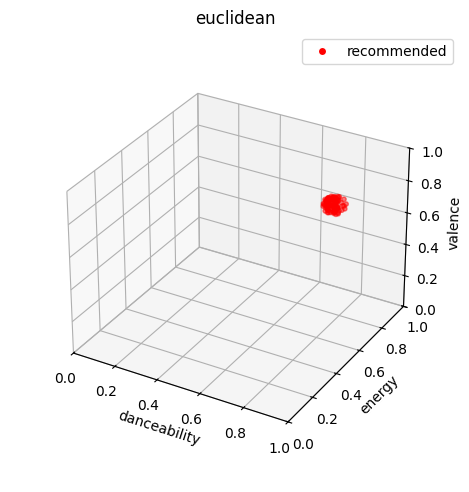

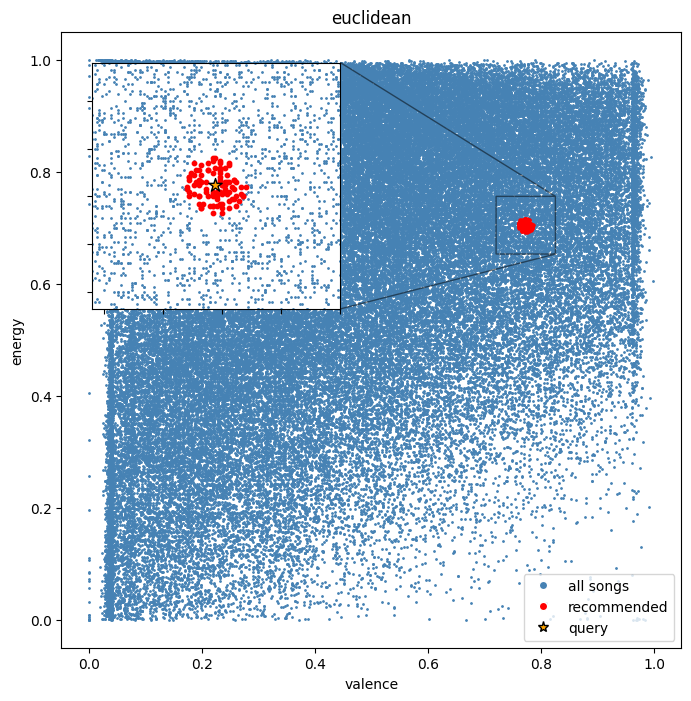

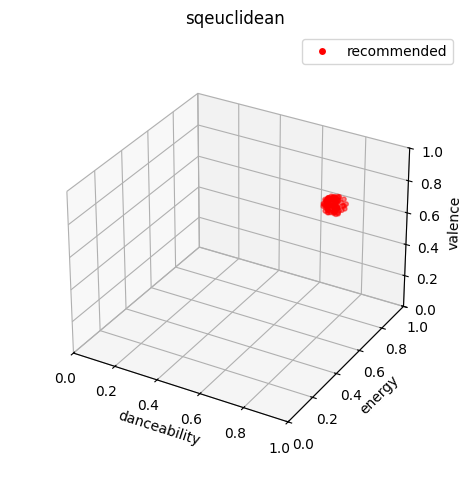

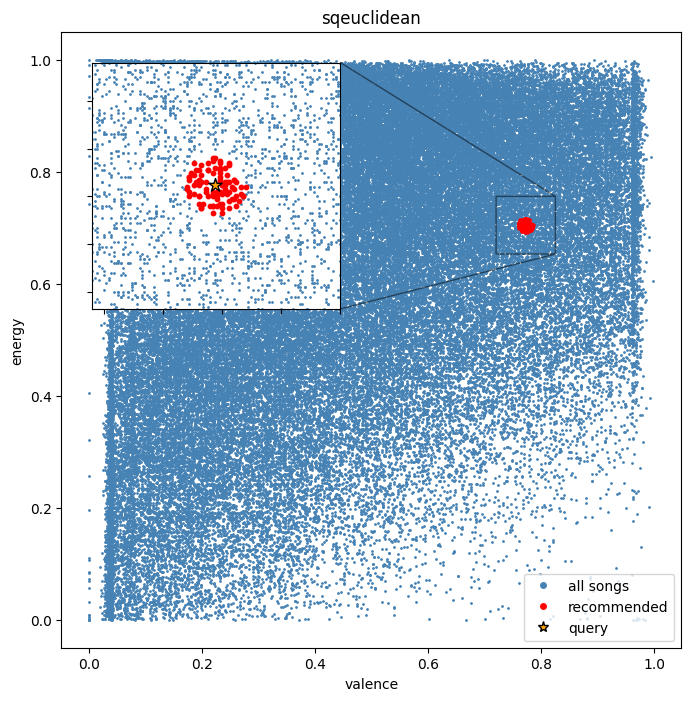

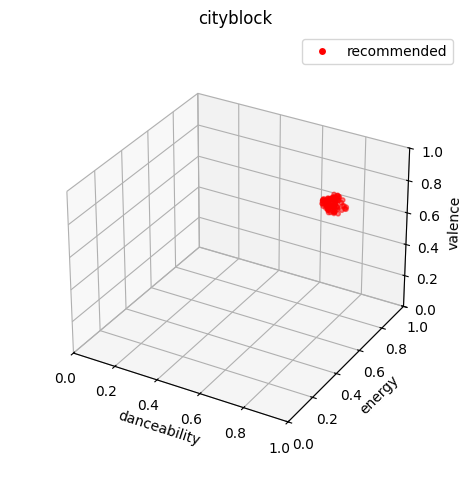

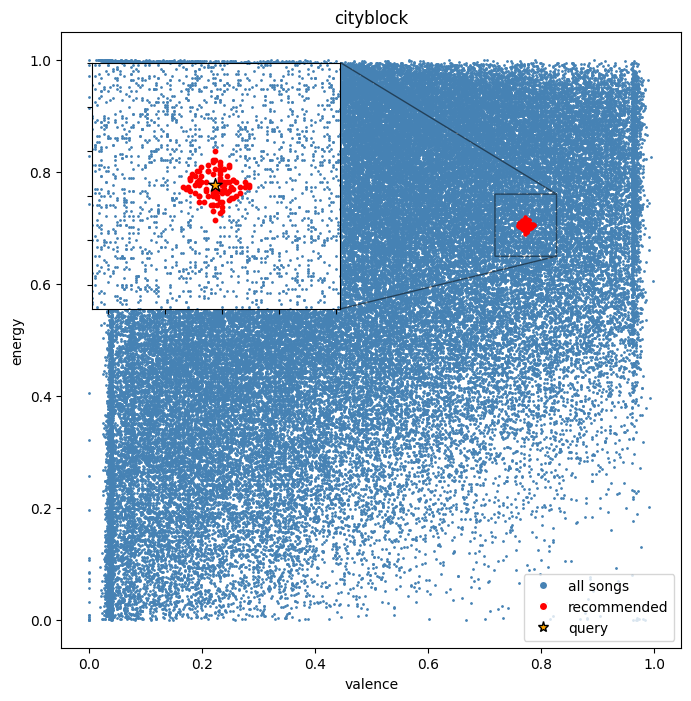

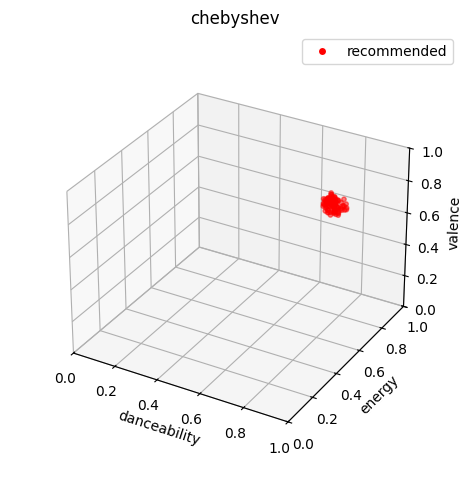

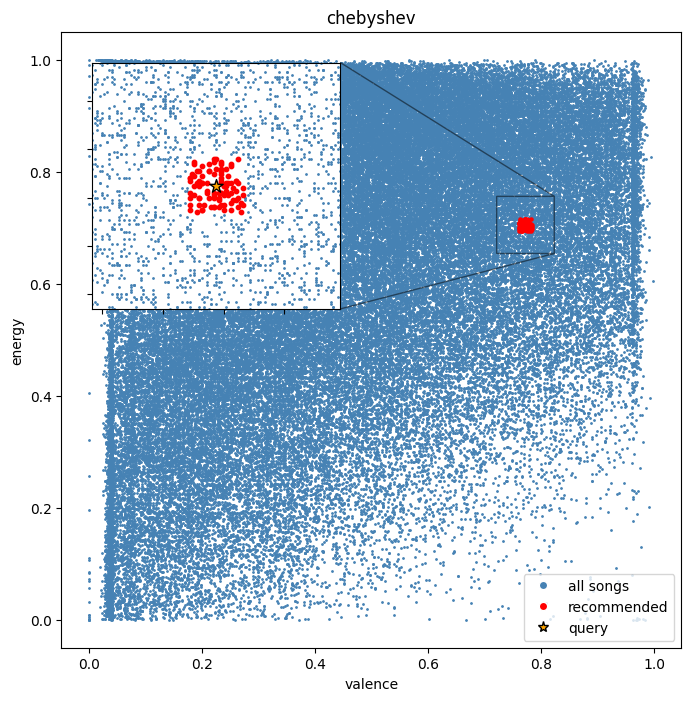

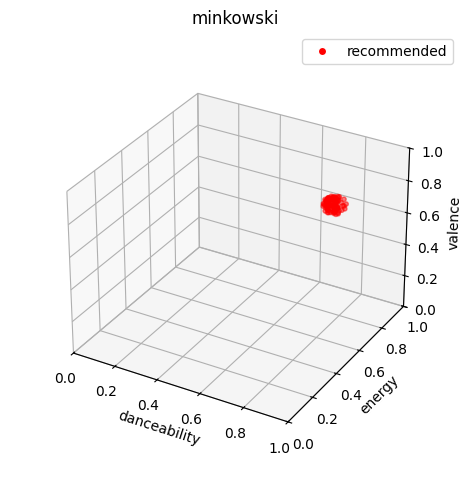

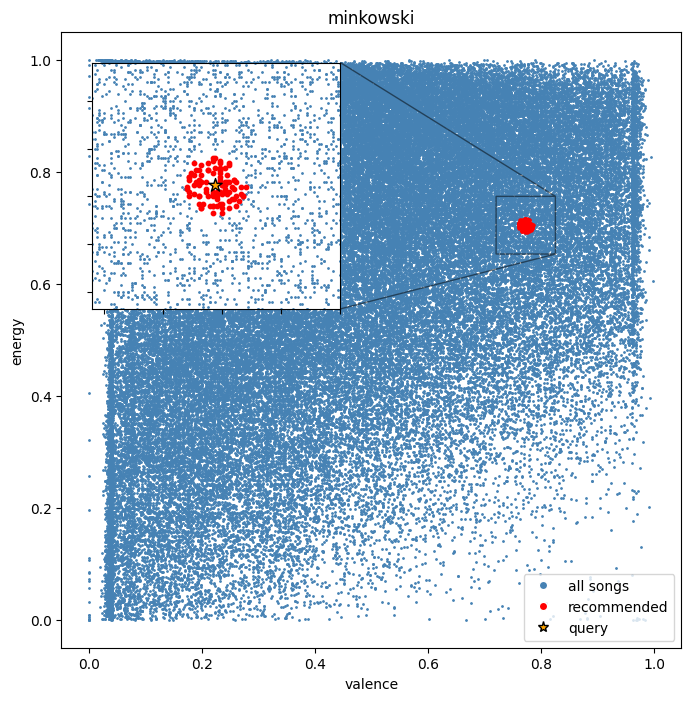

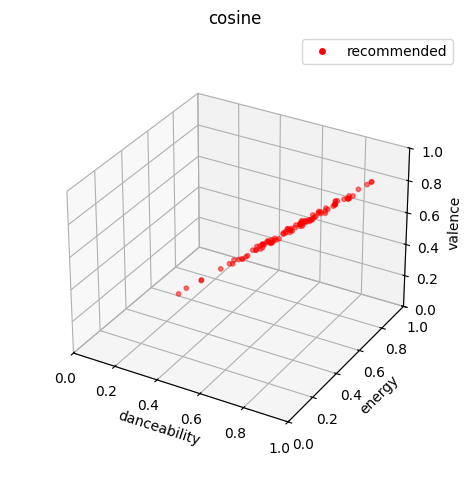

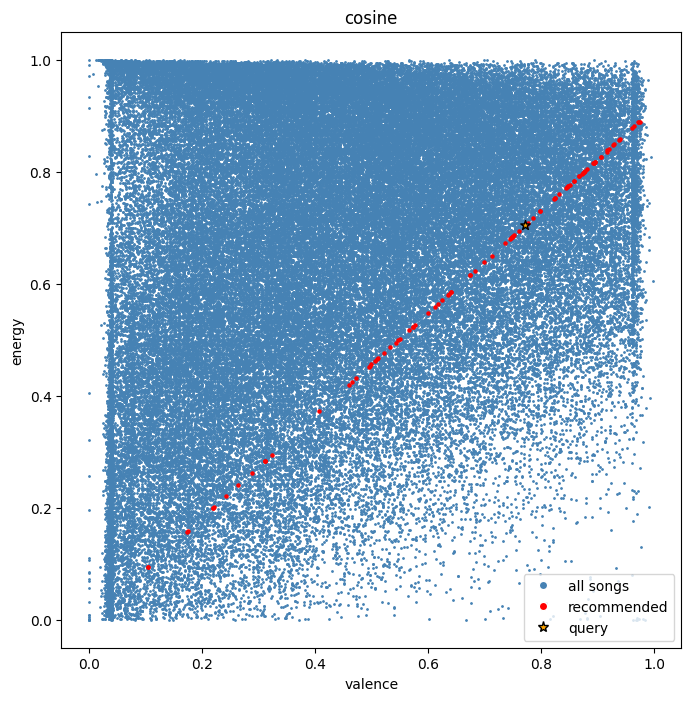

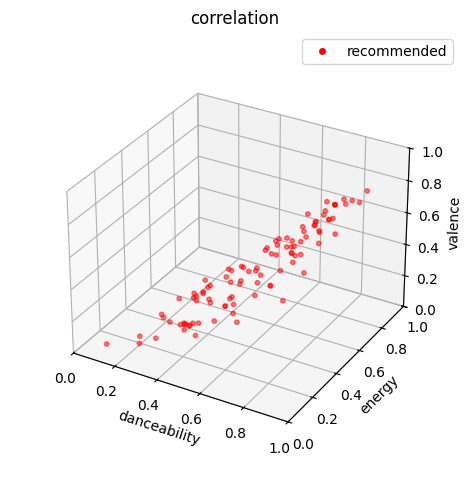

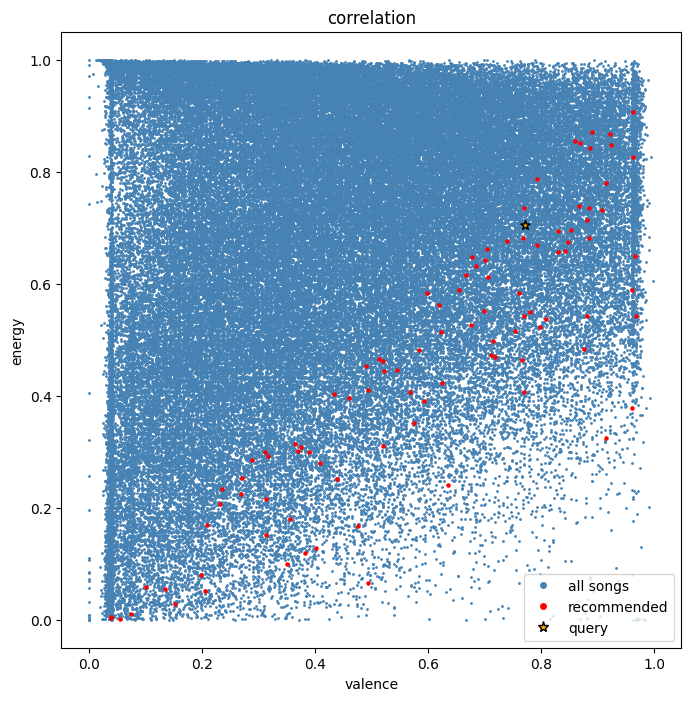

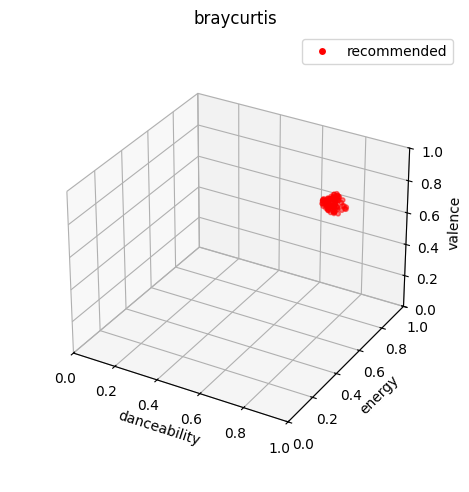

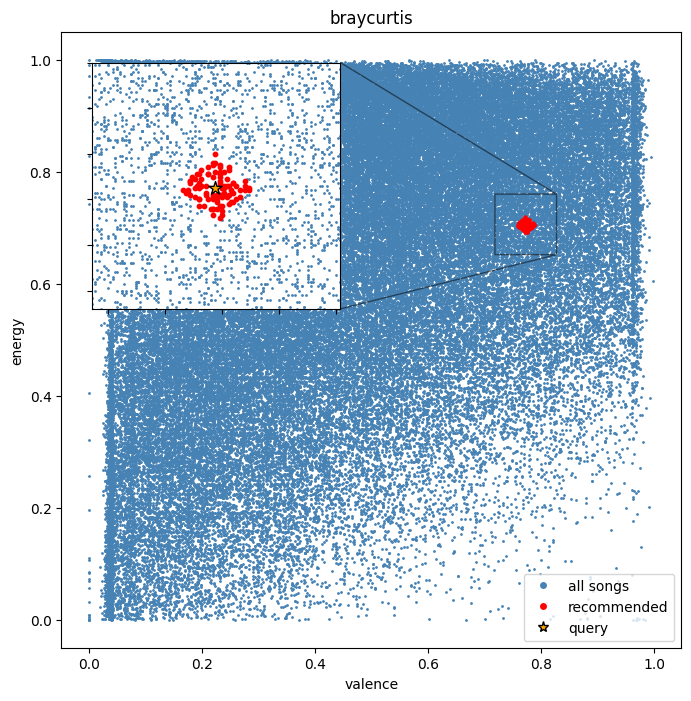

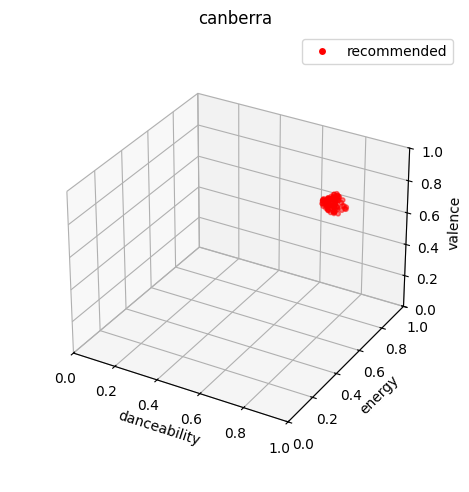

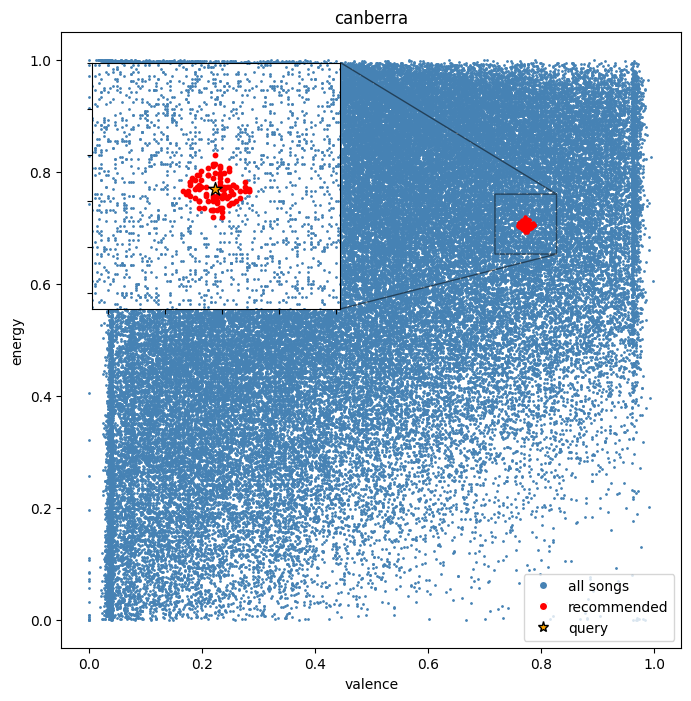

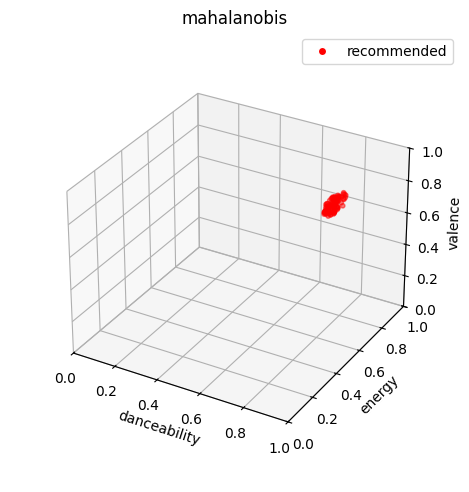

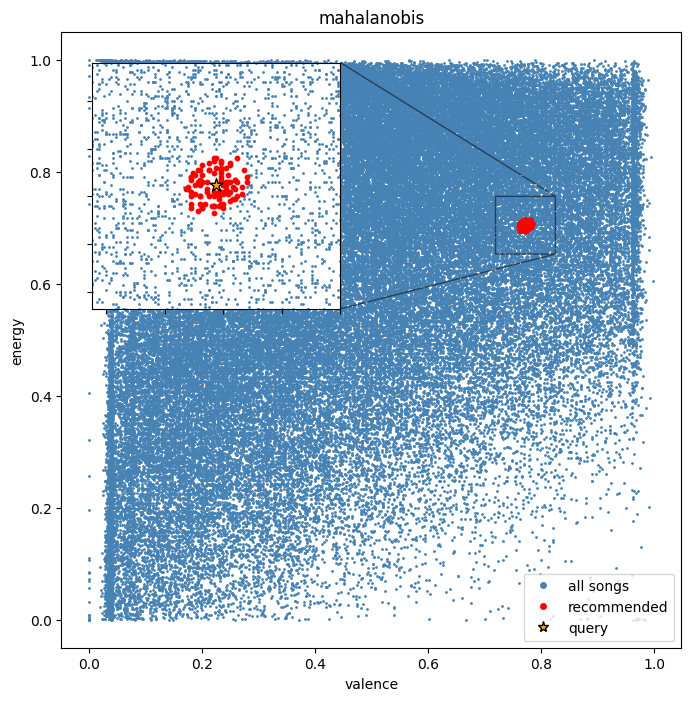

In [358]:
# example output
# for purpose of creating example scatterplots
metrics = [
    "euclidean",
    "sqeuclidean",
    "cityblock",      
    "chebyshev",
    "minkowski",
    "cosine",
    "correlation",
    "braycurtis",
    "canberra",
    "mahalanobis"
]
recommendations = []
for m in metrics:
    query = {
  "k": 100,
  "seed": {
    "artist": "Gorillaz",
    "song": "Feel Good Inc.",
    "album_name": ""
  },
  "features": {
    "danceability": 1.0,
    "energy": 1.0,
    "key": 0,
    "valence": 1.0,
    "tempo": 0.0,
    "duration_ms": 0
  },
  "constraints": {
    "include": {
      "genres": [],
      "lang": [],
      "artist": [],
      "song": [],
      "album_name": [],
      "release": [],
      "popularity": []
    },
    "exclude": {
      "genres": [],
      "lang": [],
      "artist": [],
      "song": [],
      "album_name": [],
      "release": [],
      "popularity" : []
    
    }
  }
}
    song_id = get_song_id(query["seed"], search_df)
    f_v = get_feature_vector(song_id, search_df, query["features"])
    filter_df = get_filtered_metadata(query["constraints"],search_df)
    k_indices = knn(f_v, filter_df, query["features"],query["k"], m, 2)
    k_ids = get_knn_ids(k_indices, filter_df)
    knn_recommendations = get_knn_recommendations(k_ids, filter_df)
    recommendations.append(knn_recommendations)
    plot_attributes(knn_recommendations, search_df, query["features"], f_v, m)

    query = {
  "k": 100,
  "seed": {
    "artist": "Gorillaz",
    "song": "Feel Good Inc.",
    "album_name": ""
  },
  "features": {
    "danceability": 0.0,
    "energy": 1.0,
    "key": 0,
    "valence": 1.0,
    "tempo": 0.0,
    "duration_ms": 0
  },
  "constraints": {
    "include": {
      "genres": [],
      "lang": [],
      "artist": [],
      "song": [],
      "album_name": [],
      "release": [],
     "popularity": []
    },
    "exclude": {
      "genres": [],
      "lang": [],
      "artist": [],
      "song": [],
      "album_name": [],
      "release": [],
     "popularity" : []
    }
  }
}
    song_id = get_song_id(query["seed"], search_df)
    f_v = get_feature_vector(song_id, search_df, query["features"])
    filter_df = get_filtered_metadata(query["constraints"],search_df)
    k_indices = knn(f_v, filter_df, query["features"],query["k"], m, 2)
    k_ids = get_knn_ids(k_indices, filter_df)
    knn_recommendations = get_knn_recommendations(k_ids, search_df)
    plot_attributes(knn_recommendations, search_df, query["features"], f_v, m)


In [359]:
print(metrics[0])
recommendations[0]
recommendations[0].to_csv(f'{metrics[0]}.csv', index=False)


euclidean


In [360]:
print(metrics[1])
recommendations[1]
recommendations[1].to_csv(f'{metrics[1]}.csv', index=False)

sqeuclidean


In [361]:
print(metrics[2])
recommendations[2]
recommendations[2].to_csv(f'{metrics[2]}.csv', index=False)

cityblock


In [362]:
print(metrics[3])
recommendations[3]
recommendations[3].to_csv(f'{metrics[3]}.csv', index=False)

chebyshev


In [363]:
print(metrics[4])
recommendations[4]
recommendations[4].to_csv(f'{metrics[4]}.csv', index=False)

minkowski


In [364]:
print(metrics[5])
recommendations[5]
recommendations[5].to_csv(f'{metrics[5]}.csv', index=False)

cosine


In [365]:
print(metrics[6])
recommendations[6]
recommendations[6].to_csv(f'{metrics[6]}.csv', index=False)

correlation


In [366]:
print(metrics[7])
recommendations[7]
recommendations[7].to_csv(f'{metrics[7]}.csv', index=False)

braycurtis


In [367]:
print(metrics[8])
recommendations[8]
recommendations[8].to_csv(f'{metrics[8]}.csv', index=False)

canberra


In [368]:
print(metrics[9])
recommendations[9]
recommendations[9].to_csv(f'{metrics[9]}.csv', index=False)

mahalanobis
